**Python Project 2**

*Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

*Data

In [53]:
df = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

*I'm using the methods df.describe(), df.head(), df.columns and df.info() to see the data

In [54]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [55]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [56]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

*With this data I would like to understand the most common medicine that doctors prescribe depending on the A1C results. The A1C tests measure average blood sugar over 3 months, with results reported as a percentage.

*Cleaning Data

Since I don't know the data well, I want to make sure that I try to eliminate the most possibles null values. In my previous project it was easier because I just needed numeric values.
np.nan indicates that the value is missing and it just ignore the value in my calculations.

In [58]:
null_values = ["?", "None", "NONE", "null", "NULL", "", "NaN", "nan"]

df = df.replace(null_values, np.nan)

I want to see in my data how many values were missing on each column to understand better my conclusions. I'm using df.isna() that will check how many times I have np.nan (the new value that I used to replace the nulls). I'm using sum() to sum all the values and Im sorting them to see the columns with the most missing values.

In [59]:
df.isna().sum().sort_values(ascending=False)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


I see that the columns for the medicines didn't have null values, however my A1C have a lot of missing values. Then the analysis I'm doing is limited for patients that actually checked their A1C. They were many patients that didn't do the test.

Since I have many rows without the A1C value that is the most important factor for my research, then I will use df.dropna() for the null values and only keep the data associated with a valid A1C.

In [60]:
df_a1c = df.dropna(subset=["A1Cresult"])

Checking how many nulls I have after using df.dropna() and checking how my information changed from the original df.info()

In [61]:
df_a1c['A1Cresult'].isna().sum()

np.int64(0)

In [62]:
df_a1c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17018 entries, 26 to 101761
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              17018 non-null  int64 
 1   patient_nbr               17018 non-null  int64 
 2   race                      16596 non-null  object
 3   gender                    17018 non-null  object
 4   age                       17018 non-null  object
 5   weight                    346 non-null    object
 6   admission_type_id         17018 non-null  int64 
 7   discharge_disposition_id  17018 non-null  int64 
 8   admission_source_id       17018 non-null  int64 
 9   time_in_hospital          17018 non-null  int64 
 10  payer_code                10128 non-null  object
 11  medical_specialty         9011 non-null   object
 12  num_lab_procedures        17018 non-null  int64 
 13  num_procedures            17018 non-null  int64 
 14  num_medications          

Now that I have my data without nulls, I want to see how my A1C data looks like since I have to use the A1C ranges for the medicine used.

In [63]:
df['A1Cresult'].unique()

array([nan, '>7', '>8', 'Norm'], dtype=object)

My original idea was to evaluate based on usual diabetes parameters (Normal levels: below 5.7%, Prediabetes: 5.7% to 6.4% and Diabetes: 6.5% or higher). However, the values for A1C in this data won't allow me to do it that way. My analysis will be based on the values that we have: >7, >8 and norm.

I can see that my medications have several type of values, but since there are not more null values, any input that is not the word "no", it means that the patient is using that medicine.

I'm using metformin medicine to check if true.

In [64]:
df['metformin'].unique()


array(['No', 'Steady', 'Up', 'Down'], dtype=object)

*Processing the data: I'm creating a a list of all the medicines to indicate that those are the columns that I'm want to analize.

In [65]:
med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


I'm using If and Else to convert the strings into 0s and 1s, to be able to use numeric values for my analysis (counting, mean, etc...).

In [66]:
def convert(value):
    if value == 'No':
        return 0
    else:
        return 1

I had to include this step (.copy()) because it was giving me an error with the data.

In [67]:
df_a1c = df.dropna(subset=["A1Cresult"]).copy()

I'm using a loop to evaluate every medication and apply(convert) to convert the values to 0s and 1s.

In [68]:
for col in med_columns:
    df_a1c[col] = df_a1c[col].apply(convert)

In [69]:
df_a1c[med_columns].head()

,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,...,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone
26,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
74,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
98,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
103,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
107,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


I'm using groupby to group the patients by A1C group and I'm getting the mean for each medicine/group.

In [70]:
a1c_med = df_a1c.groupby('A1Cresult')[med_columns].mean()
print(a1c_med)

           metformin  repaglinide  nateglinide  chlorpropamide  glimepiride  \
A1Cresult                                                                     
>7          0.234785     0.027807     0.007608        0.001049     0.063746   
>8          0.253773     0.021787     0.006329        0.000365     0.066091   
Norm        0.197395     0.015631     0.007615        0.000802     0.043888   

           acetohexamide  glipizide  glyburide  tolbutamide  pioglitazone  \
A1Cresult                                                                   
>7                   0.0   0.135100   0.116474     0.000000      0.073977   
>8                   0.0   0.145204   0.115750     0.000243      0.073393   
Norm                 0.0   0.110621   0.088577     0.000000      0.071142   

           ...  troglitazone  tolazamide  examide  citoglipton   insulin  \
A1Cresult  ...                                                             
>7         ...           0.0    0.000787      0.0          0.0  0.

This data was hard to see in the above format, then I'm finding the highest value to understand the most common prescribed medicine using idxmax(axis=1).

In [71]:
most_common = a1c_med.idxmax(axis=1)
print(most_common)

A1Cresult
>7      insulin
>8      insulin
Norm    insulin
dtype: object


*Visuals: This first graph is just about how many patients we have for each category in the data.

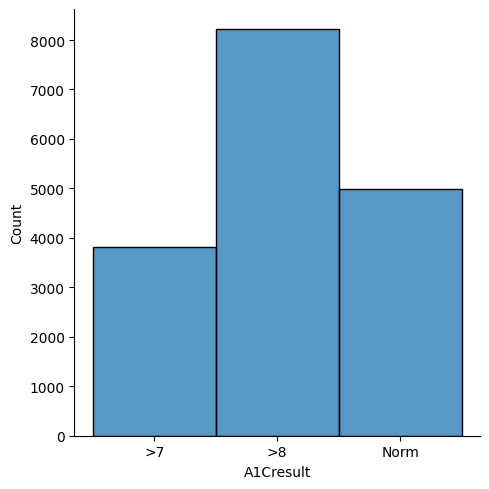

In [76]:
sns.displot(df_a1c['A1Cresult'])

This graph compares insulin usage within each A1C category. For patients with an A1C result higher than 8, there is a significantly higher count of patients prescribed insulin compared to those who are not. This suggests that as A1C levels increase, insulin becomes a primary treatment method.

<Axes: xlabel='A1Cresult', ylabel='count'>

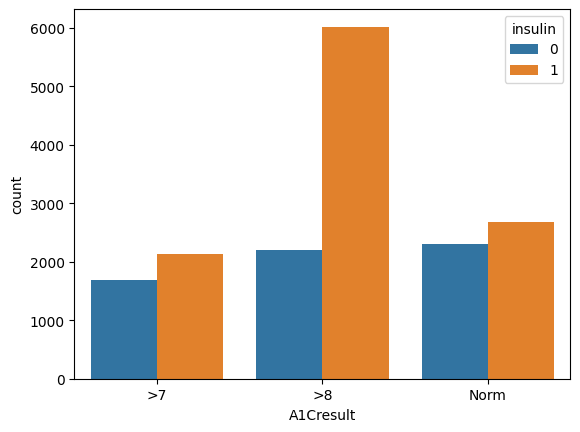

In [79]:
sns.countplot(data=df_a1c, x='A1Cresult', hue='insulin')

*Conclusion: After looking at the data, it's clear that insulin is the most used medicine for all patients who had an A1C test. This is especially true for patients with the highest blood sugar (A1C > 8), who use insulin more than any other treatment.